In [11]:
# Cell 1
# Environment and GPU Check

import sys
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU not available. Please select a T4 GPU runtime."
    )

Python version: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [12]:
# Cell 2
# Connect Google Drive and Create Project Folder

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/neural-video-compression"
)

PROJECT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Project folder:")
print(PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder:
/content/drive/MyDrive/neural-video-compression


In [13]:
# Cell 2
# Connect Google Drive and Create Project Folder

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/neural-video-compression"
)

PROJECT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

print("Project folder:")
print(PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder:
/content/drive/MyDrive/neural-video-compression


In [14]:
# Cell 3
# Create Project Directory Structure

directories = [
    "data/raw",
    "data/frames",
    "data/train",
    "data/val",
    "data/test",
    "models",
    "training",
    "inference",
    "evaluation",
    "utils",
    "configs",
    "checkpoints",
    "results"
]

for directory in directories:
    (PROJECT_ROOT / directory).mkdir(
        parents=True,
        exist_ok=True
    )

print("Project structure created successfully.")
print("\nLocation:")
print(PROJECT_ROOT)

Project structure created successfully.

Location:
/content/drive/MyDrive/neural-video-compression


In [15]:
# Cell 4
# Install Required Libraries

!pip -q install \
    opencv-python \
    pillow \
    matplotlib \
    numpy \
    tqdm \
    pyyaml \
    pandas

In [16]:
# Cell 5
# Verify FFmpeg and OpenCV

import cv2

print("OpenCV version:", cv2.__version__)

!ffmpeg -version | head -n 1


OpenCV version: 5.0.0
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers


In [17]:
# Cell 6
# Prepare Dataset Location

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "vimeo90k_mini"
)

DATASET_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Dataset location:")
print(DATASET_DIR)

Dataset location:
/content/drive/MyDrive/neural-video-compression/data/vimeo90k_mini


In [18]:
# Cell 7
# Install Dataset Download Library

!pip -q install datasets

In [20]:
# Cell 9
# Verify Downloaded Dataset

from pathlib import Path

sequence_dirs = sorted([
    p for p in DATASET_DIR.iterdir()
    if p.is_dir()
])

print("Number of sequences:", len(sequence_dirs))

if len(sequence_dirs) == NUM_SEQUENCES:
    print("Dataset verification: PASSED")
else:
    print("Dataset verification: CHECK REQUIRED")

print("Dataset location:")
print(DATASET_DIR)

Number of sequences: 1000
Dataset verification: PASSED
Dataset location:
/content/drive/MyDrive/neural-video-compression/data/vimeo90k_mini


In [21]:
# Cell 10
# Inspect Dataset Frame Dimensions

from PIL import Image

sample_sequence = sequence_dirs[0]

frame_paths = [
    sample_sequence / "frame_01.png",
    sample_sequence / "frame_02.png",
    sample_sequence / "frame_03.png"
]

print("Sample sequence:", sample_sequence.name)

for frame_path in frame_paths:
    with Image.open(frame_path) as image:
        print(
            f"{frame_path.name}: "
            f"size={image.size}, "
            f"mode={image.mode}"
        )

Sample sequence: 00001_0027
frame_01.png: size=(448, 256), mode=RGB
frame_02.png: size=(448, 256), mode=RGB
frame_03.png: size=(448, 256), mode=RGB


In [22]:
# Cell 11
# Create Train Validation Test Split

import random
import json

random.seed(42)

sequences = sequence_dirs.copy()
random.shuffle(sequences)

total = len(sequences)

train_count = int(total * 0.80)
val_count = int(total * 0.10)

train_sequences = sequences[:train_count]
val_sequences = sequences[
    train_count:train_count + val_count
]
test_sequences = sequences[
    train_count + val_count:
]

splits = {
    "train": [p.name for p in train_sequences],
    "val": [p.name for p in val_sequences],
    "test": [p.name for p in test_sequences]
}

split_path = DATASET_DIR / "splits.json"

with open(split_path, "w") as f:
    json.dump(splits, f, indent=2)

print("Train sequences:", len(train_sequences))
print("Validation sequences:", len(val_sequences))
print("Test sequences:", len(test_sequences))
print("Split saved to:", split_path)

Train sequences: 800
Validation sequences: 100
Test sequences: 100
Split saved to: /content/drive/MyDrive/neural-video-compression/data/vimeo90k_mini/splits.json


In [23]:
# Cell 12
# PyTorch Video Sequence Dataset

import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import json


class VideoSequenceDataset(Dataset):
    def __init__(self, root_dir, split):
        self.root_dir = Path(root_dir)

        with open(
            self.root_dir / "splits.json",
            "r"
        ) as f:
            splits = json.load(f)

        if split not in splits:
            raise ValueError(
                f"Unknown split: {split}"
            )

        self.sequence_ids = splits[split]

        self.transform = transforms.ToTensor()

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]

        sequence_dir = (
            self.root_dir / sequence_id
        )

        frames = []

        for frame_number in range(1, 4):

            frame_path = (
                sequence_dir
                / f"frame_{frame_number:02d}.png"
            )

            image = Image.open(
                frame_path
            ).convert("RGB")

            image = self.transform(image)

            frames.append(image)

        return {
            "frame_1": frames[0],
            "frame_2": frames[1],
            "frame_3": frames[2],
            "sequence_id": sequence_id
        }


print("Dataset class created.")

Dataset class created.


In [24]:
# Cell 13
# Create Train Validation Test Datasets

train_dataset = VideoSequenceDataset(
    DATASET_DIR,
    "train"
)

val_dataset = VideoSequenceDataset(
    DATASET_DIR,
    "val"
)

test_dataset = VideoSequenceDataset(
    DATASET_DIR,
    "test"
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 800
Validation samples: 100
Test samples: 100


In [25]:
# Cell 14
# Verify Dataset Sample

sample = train_dataset[0]

print("Sequence ID:", sample["sequence_id"])

for name in [
    "frame_1",
    "frame_2",
    "frame_3"
]:
    tensor = sample[name]

    print(
        f"{name}: "
        f"shape={tensor.shape}, "
        f"dtype={tensor.dtype}, "
        f"range="
        f"[{tensor.min().item():.3f}, "
        f"{tensor.max().item():.3f}]"
    )

Sequence ID: 00061_0206
frame_1: shape=torch.Size([3, 256, 448]), dtype=torch.float32, range=[0.000, 0.698]
frame_2: shape=torch.Size([3, 256, 448]), dtype=torch.float32, range=[0.000, 0.694]
frame_3: shape=torch.Size([3, 256, 448]), dtype=torch.float32, range=[0.000, 0.702]


In [26]:
# Cell 15
# Create DataLoaders

from torch.utils.data import DataLoader

BATCH_SIZE = 4
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 200
Validation batches: 25
Test batches: 25


In [27]:
# Cell 16
# Verify Training Batch

batch = next(iter(train_loader))

print("Frame 1:", batch["frame_1"].shape)
print("Frame 2:", batch["frame_2"].shape)
print("Frame 3:", batch["frame_3"].shape)
print("Data type:", batch["frame_1"].dtype)

Frame 1: torch.Size([4, 3, 256, 448])
Frame 2: torch.Size([4, 3, 256, 448])
Frame 3: torch.Size([4, 3, 256, 448])
Data type: torch.float32


In [28]:
# Cell 17
# Verify GPU Transfer

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

frame_batch = batch["frame_1"].to(device)

print("Device:", device)
print("Tensor device:", frame_batch.device)
print("Tensor shape:", frame_batch.shape)

Device: cuda
Tensor device: cuda:0
Tensor shape: torch.Size([4, 3, 256, 448])


In [29]:
# Cell 18
# Motion Estimation Network

import torch.nn as nn


class MotionEstimationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            # Input: previous RGB frame + current RGB frame
            # 3 + 3 = 6 channels
            nn.Conv2d(
                6, 32,
                kernel_size=7,
                stride=2,
                padding=3
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32, 64,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64, 96,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                96, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),

            # Restore spatial resolution
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                32, 16,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(inplace=True),

            # Output: 2 channels = horizontal + vertical motion
            nn.Conv2d(
                16, 2,
                kernel_size=3,
                stride=1,
                padding=1
            )
        )

    def forward(self, previous_frame, current_frame):
        x = torch.cat(
            [previous_frame, current_frame],
            dim=1
        )

        flow = self.network(x)

        return flow


motion_net = MotionEstimationNetwork().to(device)

print("Motion estimation network created.")
print("Parameters:", sum(
    p.numel() for p in motion_net.parameters()
))

Motion estimation network created.
Parameters: 212754


In [30]:
# Cell 19
# Test Motion Estimation Forward Pass

previous_frame = batch["frame_1"].to(device)
current_frame = batch["frame_2"].to(device)

with torch.no_grad():
    flow = motion_net(
        previous_frame,
        current_frame
    )

print("Previous frame:", previous_frame.shape)
print("Current frame :", current_frame.shape)
print("Predicted flow:", flow.shape)

Previous frame: torch.Size([4, 3, 256, 448])
Current frame : torch.Size([4, 3, 256, 448])
Predicted flow: torch.Size([4, 2, 256, 448])


In [31]:
# Cell 20
# Differentiable Frame Warping

import torch.nn.functional as F


def warp_frame(frame, flow):
    """
    Warp a frame using a predicted optical-flow field.

    frame: [B, 3, H, W]
    flow:  [B, 2, H, W]
    """

    B, C, H, W = frame.shape

    # Create pixel coordinate grid
    y, x = torch.meshgrid(
        torch.arange(H, device=frame.device),
        torch.arange(W, device=frame.device),
        indexing="ij"
    )

    grid = torch.stack((x, y), dim=0).float()
    grid = grid.unsqueeze(0).expand(B, -1, -1, -1)

    # Apply predicted displacement
    sampling_grid = grid + flow

    # Normalize coordinates to [-1, 1]
    sampling_grid[:, 0] = (
        2.0 * sampling_grid[:, 0] / max(W - 1, 1)
        - 1.0
    )

    sampling_grid[:, 1] = (
        2.0 * sampling_grid[:, 1] / max(H - 1, 1)
        - 1.0
    )

    # grid_sample expects [B, H, W, 2]
    sampling_grid = sampling_grid.permute(
        0, 2, 3, 1
    )

    warped_frame = F.grid_sample(
        frame,
        sampling_grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True
    )

    return warped_frame

In [32]:
# Cell 21
# Test Frame Warping

with torch.no_grad():
    warped_frame = warp_frame(
        previous_frame,
        flow
    )

print("Previous frame:", previous_frame.shape)
print("Flow          :", flow.shape)
print("Warped frame  :", warped_frame.shape)

Previous frame: torch.Size([4, 3, 256, 448])
Flow          : torch.Size([4, 2, 256, 448])
Warped frame  : torch.Size([4, 3, 256, 448])


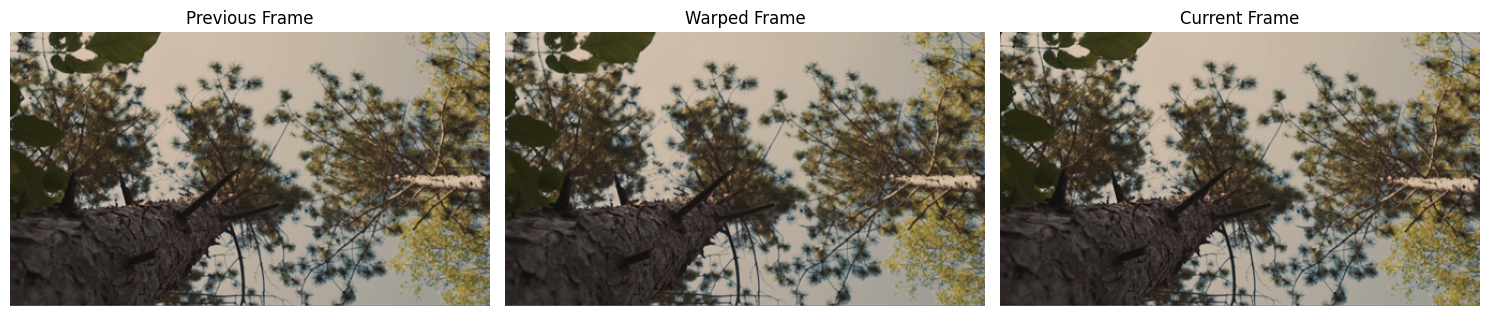

In [33]:
# Cell 22
# Visualize Motion Compensation

import matplotlib.pyplot as plt

index = 0

previous_image = (
    previous_frame[index]
    .detach()
    .cpu()
    .permute(1, 2, 0)
)

warped_image = (
    warped_frame[index]
    .detach()
    .cpu()
    .permute(1, 2, 0)
)

current_image = (
    current_frame[index]
    .detach()
    .cpu()
    .permute(1, 2, 0)
)

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

axes[0].imshow(previous_image)
axes[0].set_title("Previous Frame")

axes[1].imshow(warped_image)
axes[1].set_title("Warped Frame")

axes[2].imshow(current_image)
axes[2].set_title("Current Frame")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [34]:
# Cell 23
# Residual Computation

residual = current_frame - warped_frame

print("Current frame :", current_frame.shape)
print("Warped frame  :", warped_frame.shape)
print("Residual      :", residual.shape)

print("\nResidual statistics:")
print("Mean:", residual.mean().item())
print("Std :", residual.std().item())
print("Min :", residual.min().item())
print("Max :", residual.max().item())

Current frame : torch.Size([4, 3, 256, 448])
Warped frame  : torch.Size([4, 3, 256, 448])
Residual      : torch.Size([4, 3, 256, 448])

Residual statistics:
Mean: -0.0004884599475190043
Std : 0.10427404195070267
Min : -0.9519304633140564
Max : 0.9569219946861267


In [35]:
# Cell 24
# Residual Energy Analysis

original_energy = torch.mean(
    current_frame ** 2
)

residual_energy = torch.mean(
    residual ** 2
)

reduction = (
    1.0 - residual_energy / (original_energy + 1e-8)
) * 100.0

print(
    f"Original frame energy: "
    f"{original_energy.item():.6f}"
)

print(
    f"Residual energy      : "
    f"{residual_energy.item():.6f}"
)

print(
    f"Energy reduction     : "
    f"{reduction.item():.2f}%"
)

Original frame energy: 0.196687
Residual energy      : 0.010873
Energy reduction     : 94.47%


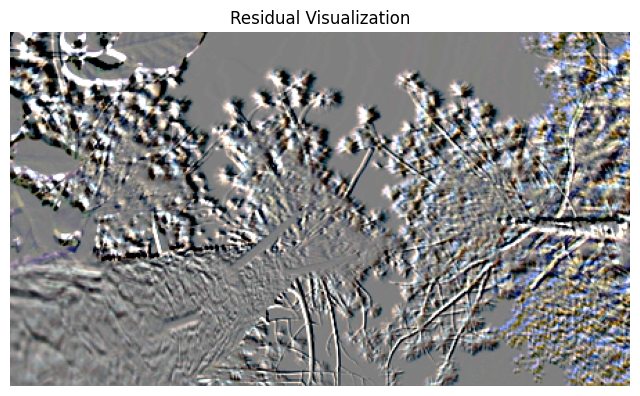

In [36]:
# Cell 25
# Visualize Residual

index = 0

residual_image = (
    residual[index]
    .detach()
    .cpu()
    .permute(1, 2, 0)
)

plt.figure(figsize=(8, 5))

plt.imshow(
    residual_image * 2.0 + 0.5
)

plt.title("Residual Visualization")
plt.axis("off")

plt.show()

# Stage 3 — Residual Compression

In [37]:
# Cell 26
# Residual Encoder

class ResidualEncoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(
                3, 64,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64, 128,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                128, latent_channels,
                kernel_size=5,
                stride=2,
                padding=2
            )
        )

    def forward(self, residual):
        return self.encoder(residual)


residual_encoder = ResidualEncoder(
    latent_channels=64
).to(device)

print("Residual encoder created.")
print(
    "Parameters:",
    sum(p.numel() for p in residual_encoder.parameters())
)

Residual encoder created.
Parameters: 414656


In [38]:
# Cell 27
# Test Residual Encoder

with torch.no_grad():
    latent = residual_encoder(residual)

print("Residual shape:", residual.shape)
print("Latent shape  :", latent.shape)

Residual shape: torch.Size([4, 3, 256, 448])
Latent shape  : torch.Size([4, 64, 32, 56])


In [39]:
# Cell 28
# Residual Decoder

class ResidualDecoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                latent_channels, 128,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                64, 3,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            )
        )

    def forward(self, latent):
        return self.decoder(latent)


residual_decoder = ResidualDecoder(
    latent_channels=64
).to(device)

print("Residual decoder created.")
print(
    "Parameters:",
    sum(p.numel() for p in residual_decoder.parameters())
)

Residual decoder created.
Parameters: 414595


In [40]:
# Cell 29
# Test Residual Encoder and Decoder

with torch.no_grad():
    latent = residual_encoder(residual)

    reconstructed_residual = residual_decoder(
        latent
    )

print("Residual shape               :", residual.shape)
print("Latent shape                 :", latent.shape)
print("Reconstructed residual shape:", reconstructed_residual.shape)

Residual shape               : torch.Size([4, 3, 256, 448])
Latent shape                 : torch.Size([4, 64, 32, 56])
Reconstructed residual shape: torch.Size([4, 3, 256, 448])


In [41]:
# Cell 30
# Latent Quantization

def quantize_latent(latent):
    return torch.round(latent)


with torch.no_grad():
    quantized_latent = quantize_latent(
        latent
    )

print("Latent shape          :", latent.shape)
print("Quantized latent shape:", quantized_latent.shape)

print("\nSample latent values:")
print(latent.flatten()[:10])

print("\nSample quantized values:")
print(quantized_latent.flatten()[:10])

Latent shape          : torch.Size([4, 64, 32, 56])
Quantized latent shape: torch.Size([4, 64, 32, 56])

Sample latent values:
tensor([-0.0361, -0.0267, -0.0060, -0.0337, -0.0345, -0.0243, -0.0457, -0.0184,
        -0.0223, -0.0202], device='cuda:0')

Sample quantized values:
tensor([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0.], device='cuda:0')


In [42]:
# Cell 31
# Reconstruct Residual from Quantized Latent

with torch.no_grad():
    reconstructed_residual = residual_decoder(
        quantized_latent
    )

print(
    "Quantized latent shape      :",
    quantized_latent.shape
)

print(
    "Reconstructed residual shape:",
    reconstructed_residual.shape
)

Quantized latent shape      : torch.Size([4, 64, 32, 56])
Reconstructed residual shape: torch.Size([4, 3, 256, 448])


In [43]:
# Cell 32
# Complete Neural Video Compression Model

class NeuralVideoCompressionModel(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        self.motion_net = MotionEstimationNetwork()

        self.residual_encoder = ResidualEncoder(
            latent_channels=latent_channels
        )

        self.residual_decoder = ResidualDecoder(
            latent_channels=latent_channels
        )

    def forward(self, previous_frame, current_frame):
        # Motion estimation
        flow = self.motion_net(
            previous_frame,
            current_frame
        )

        # Motion compensation
        warped_frame = warp_frame(
            previous_frame,
            flow
        )

        # Residual
        residual = (
            current_frame - warped_frame
        )

        # Residual encoding
        latent = self.residual_encoder(
            residual
        )

        # Straight-through quantization
        quantized_latent = (
            latent
            + (
                torch.round(latent) - latent
            ).detach()
        )

        # Residual decoding
        reconstructed_residual = (
            self.residual_decoder(
                quantized_latent
            )
        )

        # Final reconstruction
        reconstructed_frame = (
            warped_frame + reconstructed_residual
        )

        reconstructed_frame = torch.clamp(
            reconstructed_frame,
            0.0,
            1.0
        )

        return {
            "flow": flow,
            "warped_frame": warped_frame,
            "residual": residual,
            "latent": latent,
            "quantized_latent": quantized_latent,
            "reconstructed_residual": reconstructed_residual,
            "reconstructed_frame": reconstructed_frame
        }


model = NeuralVideoCompressionModel().to(device)

print("Complete model created.")
print(
    "Total parameters:",
    sum(p.numel() for p in model.parameters())
)

Complete model created.
Total parameters: 1042005


In [44]:
# Cell 33
# Test Complete Model Forward Pass

batch = next(iter(train_loader))

previous_frame = batch["frame_1"].to(device)
current_frame = batch["frame_2"].to(device)

with torch.no_grad():
    outputs = model(
        previous_frame,
        current_frame
    )

for name, value in outputs.items():
    print(
        f"{name:25s}: {tuple(value.shape)}"
    )

flow                     : (4, 2, 256, 448)
warped_frame             : (4, 3, 256, 448)
residual                 : (4, 3, 256, 448)
latent                   : (4, 64, 32, 56)
quantized_latent         : (4, 64, 32, 56)
reconstructed_residual   : (4, 3, 256, 448)
reconstructed_frame      : (4, 3, 256, 448)


In [45]:
# Cell 34
# Reconstruction Loss

def reconstruction_loss(
    reconstructed_frame,
    target_frame
):
    return torch.mean(
        (reconstructed_frame - target_frame) ** 2
    )


with torch.no_grad():
    mse = reconstruction_loss(
        outputs["reconstructed_frame"],
        current_frame
    )

print(f"Reconstruction MSE: {mse.item():.6f}")

Reconstruction MSE: 0.011636


In [46]:
# Cell 35
# Learned Entropy Model

class EntropyModel(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        # Learnable log-scale for each latent channel
        self.log_scale = nn.Parameter(
            torch.zeros(latent_channels)
        )

    def forward(self, latent):
        scale = torch.exp(
            self.log_scale
        ).view(1, -1, 1, 1)

        scale = torch.clamp(
            scale,
            min=1e-3,
            max=10.0
        )

        return scale


entropy_model = EntropyModel(
    latent_channels=64
).to(device)

print("Entropy model created.")
print(
    "Parameters:",
    sum(
        p.numel()
        for p in entropy_model.parameters()
    )
)

Entropy model created.
Parameters: 64


In [47]:
# Cell 36
# Gaussian Latent Likelihood

import math


def gaussian_likelihood(
    latent,
    scale
):
    """
    Estimate probability mass around
    each quantized latent value.
    """

    upper = (
        latent + 0.5
    ) / (
        scale * math.sqrt(2.0)
    )

    lower = (
        latent - 0.5
    ) / (
        scale * math.sqrt(2.0)
    )

    probability = 0.5 * (
        1.0 + torch.erf(upper)
    ) - 0.5 * (
        1.0 + torch.erf(lower)
    )

    return torch.clamp(
        probability,
        min=1e-9
    )


print("Gaussian likelihood function created.")

Gaussian likelihood function created.


In [48]:
# Cell 37
# Calculate Estimated Bits Per Pixel

def calculate_bpp(
    quantized_latent,
    entropy_model,
    image_height,
    image_width
):
    scale = entropy_model(
        quantized_latent
    )

    likelihood = gaussian_likelihood(
        quantized_latent,
        scale
    )

    # Estimated bits for each latent value
    bits = -torch.log2(
        likelihood
    )

    total_bits = bits.sum(
        dim=(1, 2, 3)
    )

    total_pixels = (
        image_height * image_width
    )

    bpp = (
        total_bits / total_pixels
    )

    return bpp.mean()


with torch.no_grad():
    bpp = calculate_bpp(
        outputs["quantized_latent"],
        entropy_model,
        current_frame.shape[2],
        current_frame.shape[3]
    )

print(f"Estimated BPP: {bpp.item():.6f}")

Estimated BPP: 1.384866


In [49]:
# Cell 38
# Rate-Distortion Loss

LAMBDA_RATE = 0.01


def rate_distortion_loss(
    reconstructed_frame,
    target_frame,
    quantized_latent,
    entropy_model,
    lambda_rate
):
    # Distortion
    mse = torch.mean(
        (reconstructed_frame - target_frame) ** 2
    )

    # Estimated rate
    bpp = calculate_bpp(
        quantized_latent,
        entropy_model,
        target_frame.shape[2],
        target_frame.shape[3]
    )

    # Rate-distortion objective
    total_loss = (
        mse + lambda_rate * bpp
    )

    return total_loss, mse, bpp


with torch.no_grad():
    loss, mse, bpp = rate_distortion_loss(
        outputs["reconstructed_frame"],
        current_frame,
        outputs["quantized_latent"],
        entropy_model,
        LAMBDA_RATE
    )

print(f"Loss: {loss.item():.6f}")
print(f"MSE : {mse.item():.6f}")
print(f"BPP : {bpp.item():.6f}")

Loss: 0.025485
MSE : 0.011636
BPP : 1.384866


In [50]:
# Cell 39
# Connect Entropy Model to Complete Codec

model.entropy_model = entropy_model

print("Entropy model attached to codec.")
print(
    "Total parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

Entropy model attached to codec.
Total parameters: 1042069


In [51]:
# Cell 40
# Test Complete Rate-Distortion Pipeline

model.eval()

with torch.no_grad():
    outputs = model(
        previous_frame,
        current_frame
    )

    loss, mse, bpp = rate_distortion_loss(
        outputs["reconstructed_frame"],
        current_frame,
        outputs["quantized_latent"],
        model.entropy_model,
        LAMBDA_RATE
    )

print(f"Rate-Distortion Loss: {loss.item():.6f}")
print(f"Reconstruction MSE  : {mse.item():.6f}")
print(f"Estimated BPP       : {bpp.item():.6f}")

Rate-Distortion Loss: 0.025485
Reconstruction MSE  : 0.011636
Estimated BPP       : 1.384866


In [52]:
# Cell 41
# Optimizer and Training Configuration

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("Learning rate:", LEARNING_RATE)
print("Weight decay :", WEIGHT_DECAY)
print("Lambda rate  :", LAMBDA_RATE)
print("Device       :", device)

Learning rate: 0.0001
Weight decay : 1e-05
Lambda rate  : 0.01
Device       : cuda


In [53]:
# Cell 42
# Training Function

from tqdm.auto import tqdm


def train_one_epoch(
    model,
    dataloader,
    optimizer,
    device,
    lambda_rate
):
    model.train()

    total_loss = 0.0
    total_mse = 0.0
    total_bpp = 0.0
    num_batches = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training"
    )

    for batch in progress_bar:

        previous_frame = batch["frame_1"].to(
            device,
            non_blocking=True
        )

        current_frame = batch["frame_2"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            previous_frame,
            current_frame
        )

        loss, mse, bpp = rate_distortion_loss(
            outputs["reconstructed_frame"],
            current_frame,
            outputs["quantized_latent"],
            model.entropy_model,
            lambda_rate
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()
        total_mse += mse.item()
        total_bpp += bpp.item()
        num_batches += 1

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            mse=f"{mse.item():.4f}",
            bpp=f"{bpp.item():.4f}"
        )

    return {
        "loss": total_loss / num_batches,
        "mse": total_mse / num_batches,
        "bpp": total_bpp / num_batches
    }


print("Training function created.")

Training function created.


In [54]:
# Cell 43
# Short Training Smoke Test

smoke_results = train_one_epoch(
    model=model,
    dataloader=train_loader,
    optimizer=optimizer,
    device=device,
    lambda_rate=LAMBDA_RATE
)

print("\nSmoke Test Results")
print(f"Loss: {smoke_results['loss']:.6f}")
print(f"MSE : {smoke_results['mse']:.6f}")
print(f"BPP : {smoke_results['bpp']:.6f}")

Training:   0%|          | 0/200 [00:00<?, ?it/s]


Smoke Test Results
Loss: 0.021301
MSE : 0.007252
BPP : 1.404926


In [55]:
# Cell 44
# Validation Function

def validate_one_epoch(
    model,
    dataloader,
    device,
    lambda_rate
):
    model.eval()

    total_loss = 0.0
    total_mse = 0.0
    total_bpp = 0.0
    num_batches = 0

    with torch.no_grad():

        for batch in tqdm(
            dataloader,
            desc="Validation"
        ):
            previous_frame = batch["frame_1"].to(
                device,
                non_blocking=True
            )

            current_frame = batch["frame_2"].to(
                device,
                non_blocking=True
            )

            outputs = model(
                previous_frame,
                current_frame
            )

            loss, mse, bpp = rate_distortion_loss(
                outputs["reconstructed_frame"],
                current_frame,
                outputs["quantized_latent"],
                model.entropy_model,
                lambda_rate
            )

            total_loss += loss.item()
            total_mse += mse.item()
            total_bpp += bpp.item()

            num_batches += 1

    return {
        "loss": total_loss / num_batches,
        "mse": total_mse / num_batches,
        "bpp": total_bpp / num_batches
    }


print("Validation function created.")

Validation function created.


In [56]:
# Cell 45
# Full Training with Automatic Checkpoints

NUM_EPOCHS = 10

CHECKPOINT_DIR = (
    PROJECT_ROOT / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

training_history = {
    "train_loss": [],
    "train_mse": [],
    "train_bpp": [],
    "val_loss": [],
    "val_mse": [],
    "val_bpp": []
}

best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):

    print(
        f"\n========== Epoch "
        f"{epoch}/{NUM_EPOCHS} =========="
    )

    train_results = train_one_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        device=device,
        lambda_rate=LAMBDA_RATE
    )

    val_results = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        device=device,
        lambda_rate=LAMBDA_RATE
    )

    training_history["train_loss"].append(
        train_results["loss"]
    )

    training_history["train_mse"].append(
        train_results["mse"]
    )

    training_history["train_bpp"].append(
        train_results["bpp"]
    )

    training_history["val_loss"].append(
        val_results["loss"]
    )

    training_history["val_mse"].append(
        val_results["mse"]
    )

    training_history["val_bpp"].append(
        val_results["bpp"]
    )

    print(
        f"Train | "
        f"Loss: {train_results['loss']:.6f} | "
        f"MSE: {train_results['mse']:.6f} | "
        f"BPP: {train_results['bpp']:.6f}"
    )

    print(
        f"Val   | "
        f"Loss: {val_results['loss']:.6f} | "
        f"MSE: {val_results['mse']:.6f} | "
        f"BPP: {val_results['bpp']:.6f}"
    )

    # Save checkpoint after every epoch
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "training_history": training_history,
        "lambda_rate": LAMBDA_RATE,
        "best_val_loss": best_val_loss
    }

    latest_path = (
        CHECKPOINT_DIR
        / "latest_checkpoint.pth"
    )

    torch.save(
        checkpoint,
        latest_path
    )

    # Save best model separately
    if val_results["loss"] < best_val_loss:

        best_val_loss = val_results["loss"]

        checkpoint["best_val_loss"] = (
            best_val_loss
        )

        best_path = (
            CHECKPOINT_DIR
            / "best_model.pth"
        )

        torch.save(
            checkpoint,
            best_path
        )

        print("✓ Best model checkpoint updated.")

    print("✓ Checkpoint saved.")


========== Epoch 1/10 ==========


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train | Loss: 0.017569 | MSE: 0.003709 | BPP: 1.385978
Val   | Loss: 0.016362 | MSE: 0.002665 | BPP: 1.369749
✓ Best model checkpoint updated.
✓ Checkpoint saved.

========== Epoch 2/10 ==========


Training:   0%|          | 0/200 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train | Loss: 0.014001 | MSE: 0.001878 | BPP: 1.212364
Val   | Loss: 0.013401 | MSE: 0.001528 | BPP: 1.187281
✓ Best model checkpoint updated.
✓ Checkpoint saved.

========== Epoch 10/10 ==========


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Train | Loss: 0.013709 | MSE: 0.001814 | BPP: 1.189579
Val   | Loss: 0.013146 | MSE: 0.001460 | BPP: 1.168563
✓ Best model checkpoint updated.
✓ Checkpoint saved.


In [59]:
# Cell 46
# Save Training History

import json

RESULTS_DIR = (
    PROJECT_ROOT / "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

history_path = (
    RESULTS_DIR
    / "training_history.json"
)

with open(history_path, "w") as f:
    json.dump(
        training_history,
        f,
        indent=2
    )

print("Training history saved:")
print(history_path)

print(
    "\nBest validation loss:",
    best_val_loss
)

Training history saved:
/content/drive/MyDrive/neural-video-compression/results/training_history.json

Best validation loss: 0.01314568154513836


In [60]:
# Cell 47
# Load Best Trained Model

BEST_MODEL_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "best_model.pth"
)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Best model not found: {BEST_MODEL_PATH}"
    )

best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("Best model loaded successfully.")
print("Checkpoint:", BEST_MODEL_PATH)
print("Best validation loss:", best_checkpoint["best_val_loss"])
print("Device:", device)

Best model loaded successfully.
Checkpoint: /content/drive/MyDrive/neural-video-compression/checkpoints/best_model.pth
Best validation loss: 0.01314568154513836
Device: cuda


In [61]:
# Cell 48
# Final Test Set Evaluation

test_results = {
    "loss": 0.0,
    "mse": 0.0,
    "bpp": 0.0
}

num_batches = 0

model.eval()

with torch.no_grad():

    for batch in tqdm(
        test_loader,
        desc="Testing"
    ):
        previous_frame = batch["frame_1"].to(
            device,
            non_blocking=True
        )

        current_frame = batch["frame_2"].to(
            device,
            non_blocking=True
        )

        outputs = model(
            previous_frame,
            current_frame
        )

        loss, mse, bpp = rate_distortion_loss(
            outputs["reconstructed_frame"],
            current_frame,
            outputs["quantized_latent"],
            model.entropy_model,
            LAMBDA_RATE
        )

        test_results["loss"] += loss.item()
        test_results["mse"] += mse.item()
        test_results["bpp"] += bpp.item()

        num_batches += 1

test_results = {
    key: value / num_batches
    for key, value in test_results.items()
}

print("\nTest Results")
print(f"Loss: {test_results['loss']:.6f}")
print(f"MSE : {test_results['mse']:.6f}")
print(f"BPP : {test_results['bpp']:.6f}")

Testing:   0%|          | 0/25 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b361b2f65c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b361b2f65c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Test Results
Loss: 0.013334
MSE : 0.001615
BPP : 1.171961


In [62]:
# Cell 49
# Calculate Test PSNR

test_mse = test_results["mse"]

if test_mse > 0:
    test_psnr = 10 * math.log10(
        1.0 / test_mse
    )
else:
    test_psnr = float("inf")

print(f"Test MSE : {test_mse:.6f}")
print(f"Test PSNR: {test_psnr:.2f} dB")
print(f"Test BPP : {test_results['bpp']:.6f}")

Test MSE : 0.001615
Test PSNR: 27.92 dB
Test BPP : 1.171961


In [63]:
# Cell 50
# Save Final Test Results

final_results = {
    "test_mse": test_results["mse"],
    "test_psnr_db": test_psnr,
    "test_bpp": test_results["bpp"],
    "lambda_rate": LAMBDA_RATE
}

results_path = (
    RESULTS_DIR / "final_test_results.json"
)

with open(results_path, "w") as f:
    json.dump(
        final_results,
        f,
        indent=2
    )

print("Final test results saved:")
print(results_path)

Final test results saved:
/content/drive/MyDrive/neural-video-compression/results/final_test_results.json


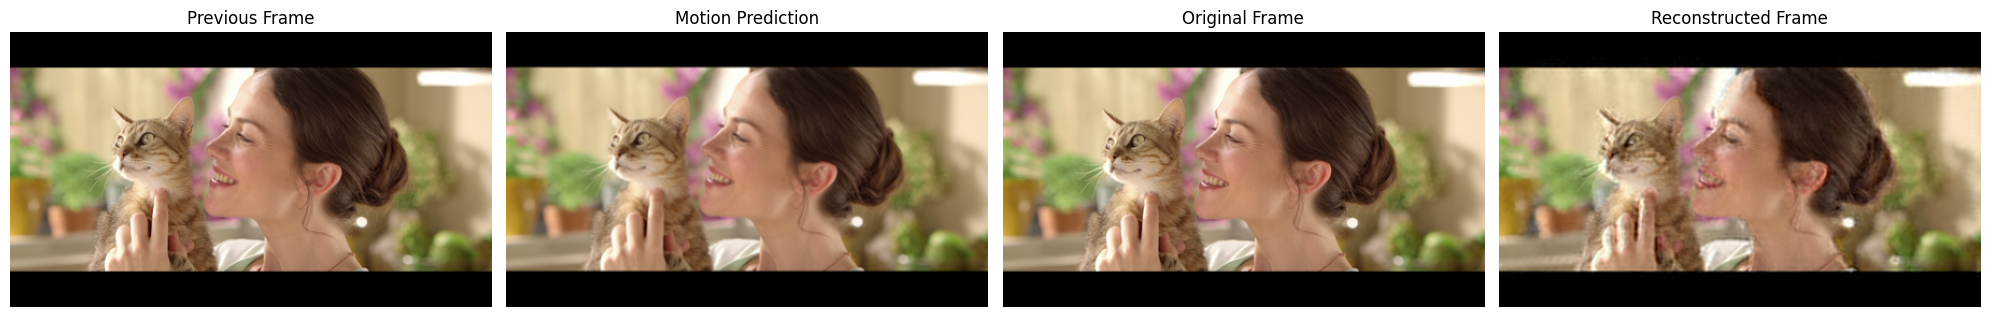

In [64]:
# Cell 51
# Visualize Test Reconstruction

model.eval()

sample = test_dataset[0]

previous_frame = sample["frame_1"].unsqueeze(0).to(device)
current_frame = sample["frame_2"].unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(
        previous_frame,
        current_frame
    )

previous_img = (
    previous_frame[0]
    .cpu()
    .permute(1, 2, 0)
)

warped_img = (
    outputs["warped_frame"][0]
    .cpu()
    .permute(1, 2, 0)
)

original_img = (
    current_frame[0]
    .cpu()
    .permute(1, 2, 0)
)

reconstructed_img = (
    outputs["reconstructed_frame"][0]
    .cpu()
    .permute(1, 2, 0)
)

fig, axes = plt.subplots(
    1, 4,
    figsize=(20, 5)
)

axes[0].imshow(previous_img)
axes[0].set_title("Previous Frame")

axes[1].imshow(warped_img)
axes[1].set_title("Motion Prediction")

axes[2].imshow(original_img)
axes[2].set_title("Original Frame")

axes[3].imshow(reconstructed_img)
axes[3].set_title("Reconstructed Frame")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [65]:
# Cell 52
# Save Test Reconstruction Figure

comparison_path = (
    RESULTS_DIR
    / "test_reconstruction_comparison.png"
)

fig.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

print("Comparison figure saved:")
print(comparison_path)

Comparison figure saved:
/content/drive/MyDrive/neural-video-compression/results/test_reconstruction_comparison.png


In [66]:
# Cell 53
# Load a Video for Inference

from google.colab import files

uploaded = files.upload()

uploaded_filename = next(iter(uploaded.keys()))

uploaded_video_path = Path(
    "/content"
) / uploaded_filename

print("Uploaded video:")
print(uploaded_video_path)

Saving video.webm to video.webm
Uploaded video:
/content/video.webm


In [68]:
# Cell 54
# Save Input Video to Google Drive

import shutil

RAW_DIR = (
    PROJECT_ROOT / "data" / "raw"
)

RAW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

drive_video_path = (
    RAW_DIR / uploaded_filename
)

shutil.copy2(
    uploaded_video_path,
    drive_video_path
)

print("Input video saved to Google Drive:")
print(drive_video_path)

Input video saved to Google Drive:
/content/drive/MyDrive/neural-video-compression/data/raw/video.webm


In [69]:
# Cell 55
# Prepare Video Inference Function

import cv2
import numpy as np


INFERENCE_WIDTH = 448
INFERENCE_HEIGHT = 256


def preprocess_video_frame(frame):
    """
    Convert an OpenCV BGR frame into a
    normalized PyTorch tensor.
    """

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    frame_rgb = cv2.resize(
        frame_rgb,
        (
            INFERENCE_WIDTH,
            INFERENCE_HEIGHT
        ),
        interpolation=cv2.INTER_AREA
    )

    image = Image.fromarray(frame_rgb)

    tensor = transforms.ToTensor()(
        image
    )

    return tensor.unsqueeze(0)

In [75]:
# Cell 56
# Improved Neural Video Compression Inference

def compress_video(
    model,
    input_path,
    output_path,
    device
):
    model.eval()

    cap = cv2.VideoCapture(
        str(input_path)
    )

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open video: {input_path}"
        )

    # Read original video properties
    original_fps = cap.get(
        cv2.CAP_PROP_FPS
    )

    original_width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    original_height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if original_fps <= 0:
        original_fps = 30.0

    # Output keeps original resolution and FPS
    fourcc = cv2.VideoWriter_fourcc(
        *"mp4v"
    )

    writer = cv2.VideoWriter(
        str(output_path),
        fourcc,
        original_fps,
        (
            original_width,
            original_height
        )
    )

    if not writer.isOpened():
        cap.release()
        raise RuntimeError(
            f"Could not create output video: {output_path}"
        )

    # --------------------------------------------------------
    # Read first frame
    # --------------------------------------------------------

    success, frame = cap.read()

    if not success:
        cap.release()
        writer.release()
        raise RuntimeError(
            "Could not read first video frame."
        )

    frame_count = 0

    # --------------------------------------------------------
    # Helper: prepare frame for the neural network
    # --------------------------------------------------------

    def prepare_frame(frame):
        frame_rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        # Preserve aspect ratio while fitting
        # inside 448 x 256.
        scale = min(
            INFERENCE_WIDTH / original_width,
            INFERENCE_HEIGHT / original_height
        )

        resized_width = int(
            round(original_width * scale)
        )

        resized_height = int(
            round(original_height * scale)
        )

        resized = cv2.resize(
            frame_rgb,
            (
                resized_width,
                resized_height
            ),
            interpolation=cv2.INTER_AREA
        )

        # Create 448 x 256 canvas
        canvas = np.zeros(
            (
                INFERENCE_HEIGHT,
                INFERENCE_WIDTH,
                3
            ),
            dtype=np.uint8
        )

        # Center the resized frame
        x_offset = (
            INFERENCE_WIDTH - resized_width
        ) // 2

        y_offset = (
            INFERENCE_HEIGHT - resized_height
        ) // 2

        canvas[
            y_offset:y_offset + resized_height,
            x_offset:x_offset + resized_width
        ] = resized

        tensor = transforms.ToTensor(
        )(Image.fromarray(canvas))

        return tensor.unsqueeze(0).to(device)

    # --------------------------------------------------------
    # Helper: restore neural-network output
    # --------------------------------------------------------

    def restore_frame(
        tensor
    ):
        image = (
            tensor[0]
            .detach()
            .cpu()
            .permute(1, 2, 0)
            .numpy()
        )

        image = np.clip(
            image * 255.0,
            0,
            255
        ).astype(np.uint8)

        # Calculate same aspect-ratio scaling
        scale = min(
            INFERENCE_WIDTH / original_width,
            INFERENCE_HEIGHT / original_height
        )

        resized_width = int(
            round(original_width * scale)
        )

        resized_height = int(
            round(original_height * scale)
        )

        x_offset = (
            INFERENCE_WIDTH - resized_width
        ) // 2

        y_offset = (
            INFERENCE_HEIGHT - resized_height
        ) // 2

        # Remove padding
        cropped = image[
            y_offset:y_offset + resized_height,
            x_offset:x_offset + resized_width
        ]

        # Restore original resolution
        restored = cv2.resize(
            cropped,
            (
                original_width,
                original_height
            ),
            interpolation=cv2.INTER_CUBIC
        )

        restored = cv2.cvtColor(
            restored,
            cv2.COLOR_RGB2BGR
        )

        return restored

    # --------------------------------------------------------
    # First frame
    # --------------------------------------------------------

    previous_tensor = prepare_frame(
        frame
    )

    first_output = restore_frame(
        previous_tensor
    )

    writer.write(first_output)

    frame_count += 1

    # --------------------------------------------------------
    # Remaining frames
    # --------------------------------------------------------

    with torch.no_grad():

        while True:

            success, frame = cap.read()

            if not success:
                break

            current_tensor = prepare_frame(
                frame
            )

            outputs = model(
                previous_tensor,
                current_tensor
            )

            reconstructed_frame = (
                restore_frame(
                    outputs[
                        "reconstructed_frame"
                    ]
                )
            )

            writer.write(
                reconstructed_frame
            )

            previous_tensor = (
                current_tensor
            )

            frame_count += 1

    cap.release()
    writer.release()

    print("Original resolution:")
    print(
        f"{original_width} x "
        f"{original_height}"
    )

    print("Output resolution:")
    print(
        f"{original_width} x "
        f"{original_height}"
    )

    print("Original frame count:", total_frames)
    print("Processed frame count:", frame_count)

    return frame_count

In [76]:
# Cell 57
# Run Improved Neural Compression

OUTPUT_VIDEO_PATH = (
    RESULTS_DIR / "compressed_video_v2.mp4"
)

frame_count = compress_video(
    model=model,
    input_path=drive_video_path,
    output_path=OUTPUT_VIDEO_PATH,
    device=device
)

print("\nCompression completed.")
print("Frames processed:", frame_count)
print("Output video:")
print(OUTPUT_VIDEO_PATH)

Original resolution:
854 x 480
Output resolution:
854 x 480
Original frame count: 1692
Processed frame count: 1691

Compression completed.
Frames processed: 1691
Output video:
/content/drive/MyDrive/neural-video-compression/results/compressed_video_v2.mp4


In [77]:
# Cell 58
# Compare Input and Reconstructed Video Properties

def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(
            f"Could not open: {video_path}"
        )

    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )
    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )
    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    cap.release()

    return {
        "frames": frames,
        "fps": fps,
        "width": width,
        "height": height
    }


# Use the new reconstructed video
OUTPUT_VIDEO_PATH = (
    RESULTS_DIR / "compressed_video_v2.mp4"
)

input_info = get_video_info(
    drive_video_path
)

output_info = get_video_info(
    OUTPUT_VIDEO_PATH
)

print("Input video:")
print(input_info)

print("\nReconstructed video:")
print(output_info)

Input video:
{'frames': 1692, 'fps': 24.0, 'width': 854, 'height': 480}

Reconstructed video:
{'frames': 1691, 'fps': 24.0, 'width': 854, 'height': 480}


In [78]:
# Cell 59
# Compare Video File Sizes

import os

input_size_mb = (
    os.path.getsize(drive_video_path)
    / (1024 ** 2)
)

output_size_mb = (
    os.path.getsize(OUTPUT_VIDEO_PATH)
    / (1024 ** 2)
)

size_ratio = (
    input_size_mb / output_size_mb
    if output_size_mb > 0
    else float("inf")
)

size_change = (
    (1 - output_size_mb / input_size_mb) * 100
    if input_size_mb > 0
    else 0.0
)

print(f"Input size  : {input_size_mb:.2f} MB")
print(f"Output size : {output_size_mb:.2f} MB")
print(f"Size ratio  : {size_ratio:.2f}x")
print(f"Size change : {size_change:.2f}%")

Input size  : 10.55 MB
Output size : 33.13 MB
Size ratio  : 0.32x
Size change : -213.92%


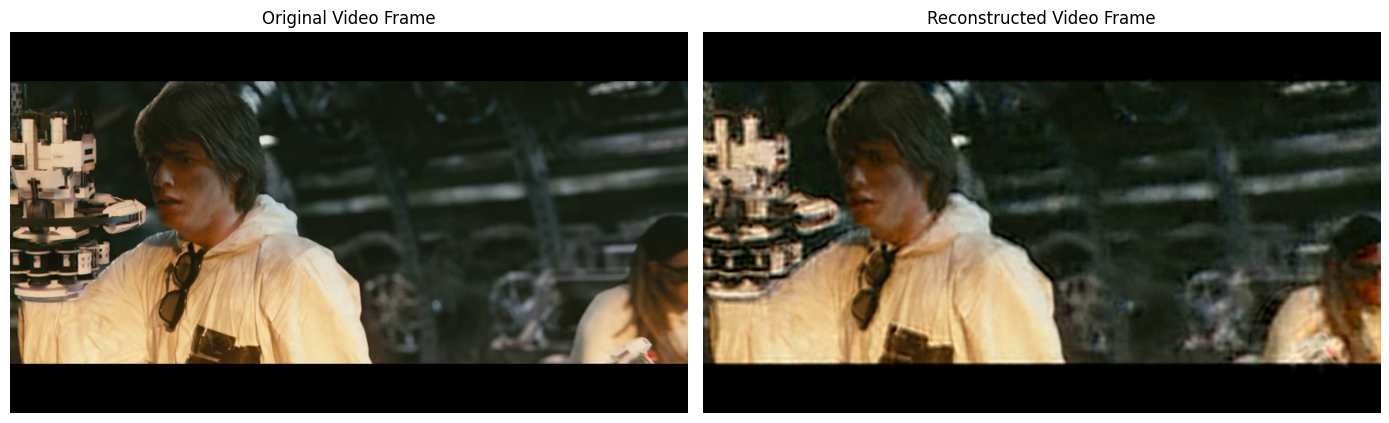

In [79]:
# Cell 60
# Visual Comparison of Original and Reconstructed Video

comparison_index = 500

input_frame = read_video_frame(
    drive_video_path,
    comparison_index
)

output_frame = read_video_frame(
    OUTPUT_VIDEO_PATH,
    comparison_index
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].imshow(input_frame)
axes[0].set_title("Original Video Frame")

axes[1].imshow(output_frame)
axes[1].set_title("Reconstructed Video Frame")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [80]:
# Cell 61
# Real Video Reconstruction Metrics

def evaluate_reconstructed_video(
    original_path,
    reconstructed_path
):
    original_cap = cv2.VideoCapture(
        str(original_path)
    )

    reconstructed_cap = cv2.VideoCapture(
        str(reconstructed_path)
    )

    if not original_cap.isOpened():
        raise RuntimeError(
            "Could not open original video."
        )

    if not reconstructed_cap.isOpened():
        raise RuntimeError(
            "Could not open reconstructed video."
        )

    total_mse = 0.0
    total_psnr = 0.0
    frame_count = 0

    while True:

        original_ok, original_frame = (
            original_cap.read()
        )

        reconstructed_ok, reconstructed_frame = (
            reconstructed_cap.read()
        )

        if not original_ok or not reconstructed_ok:
            break

        # Ensure both frames have identical dimensions
        reconstructed_frame = cv2.resize(
            reconstructed_frame,
            (
                original_frame.shape[1],
                original_frame.shape[0]
            ),
            interpolation=cv2.INTER_CUBIC
        )

        original_float = (
            original_frame.astype(np.float32)
            / 255.0
        )

        reconstructed_float = (
            reconstructed_frame.astype(np.float32)
            / 255.0
        )

        mse = np.mean(
            (original_float - reconstructed_float) ** 2
        )

        if mse > 0:
            psnr = 10 * np.log10(
                1.0 / mse
            )
        else:
            psnr = float("inf")

        total_mse += mse
        total_psnr += psnr
        frame_count += 1

    original_cap.release()
    reconstructed_cap.release()

    if frame_count == 0:
        raise RuntimeError(
            "No matching frames were available."
        )

    return {
        "frames_compared": frame_count,
        "mse": total_mse / frame_count,
        "psnr": total_psnr / frame_count
    }


video_metrics = evaluate_reconstructed_video(
    drive_video_path,
    OUTPUT_VIDEO_PATH
)

print("Frames compared:", video_metrics["frames_compared"])
print(f"MSE : {video_metrics['mse']:.6f}")
print(f"PSNR: {video_metrics['psnr']:.2f} dB")

Frames compared: 1691
MSE : 0.001741
PSNR: 28.09 dB


In [81]:
# Cell 62
# Real Video Compression Summary

input_size_mb = (
    os.path.getsize(drive_video_path)
    / (1024 ** 2)
)

output_size_mb = (
    os.path.getsize(OUTPUT_VIDEO_PATH)
    / (1024 ** 2)
)

print("========== Video Compression Summary ==========")

print(
    f"Input file size       : "
    f"{input_size_mb:.2f} MB"
)

print(
    f"Reconstructed size    : "
    f"{output_size_mb:.2f} MB"
)

print(
    f"Learned test BPP      : "
    f"{test_results['bpp']:.6f}"
)

print(
    f"Video PSNR            : "
    f"{video_metrics['psnr']:.2f} dB"
)

print(
    f"Video MSE             : "
    f"{video_metrics['mse']:.6f}"
)

print(
    f"Frames compared       : "
    f"{video_metrics['frames_compared']}"
)

print(
    f"Frame count metadata  : "
    f"{input_info['frames']} → {output_info['frames']}"
)

========== Video Compression Summary ==========
Input file size       : 10.55 MB
Reconstructed size    : 33.13 MB
Learned test BPP      : 1.171961
Video PSNR            : 28.09 dB
Video MSE             : 0.001741
Frames compared       : 1691
Frame count metadata  : 1692 → 1691


In [84]:
# Cell 63
# Save Real Video Evaluation Results

real_video_results = {
    "input_video": str(drive_video_path.name),
    "input_size_mb": float(input_size_mb),
    "reconstructed_size_mb": float(output_size_mb),
    "frames_compared": int(
        video_metrics["frames_compared"]
    ),
    "mse": float(
        video_metrics["mse"]
    ),
    "psnr_db": float(
        video_metrics["psnr"]
    ),
    "learned_test_bpp": float(
        test_results["bpp"]
    )
}

real_video_results_path = (
    RESULTS_DIR
    / "real_video_evaluation.json"
)

with open(
    real_video_results_path,
    "w"
) as f:
    json.dump(
        real_video_results,
        f,
        indent=2
    )

print("Real video evaluation saved:")
print(real_video_results_path)

Real video evaluation saved:
/content/drive/MyDrive/neural-video-compression/results/real_video_evaluation.json


In [86]:
# Cell 64
# Export Neural Codec Model for Deployment

DEPLOY_DIR = PROJECT_ROOT / "app"
DEPLOY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_file = DEPLOY_DIR / "neural_codec.py"

model_source = r'''
import torch
import torch.nn as nn
import torch.nn.functional as F


def warp_frame(frame, flow):
    # Differentiable frame warping

    B, C, H, W = frame.shape

    y, x = torch.meshgrid(
        torch.arange(H, device=frame.device),
        torch.arange(W, device=frame.device),
        indexing="ij"
    )

    grid = torch.stack(
        (x, y),
        dim=0
    ).float()

    grid = grid.unsqueeze(0).expand(
        B, -1, -1, -1
    )

    sampling_grid = grid + flow

    sampling_grid[:, 0] = (
        2.0 * sampling_grid[:, 0]
        / max(W - 1, 1)
        - 1.0
    )

    sampling_grid[:, 1] = (
        2.0 * sampling_grid[:, 1]
        / max(H - 1, 1)
        - 1.0
    )

    sampling_grid = sampling_grid.permute(
        0, 2, 3, 1
    )

    warped_frame = F.grid_sample(
        frame,
        sampling_grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True
    )

    return warped_frame


class MotionEstimationNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(
                6, 32,
                kernel_size=7,
                stride=2,
                padding=3
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32, 64,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64, 96,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                96, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                32, 16,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                16, 2,
                kernel_size=3,
                stride=1,
                padding=1
            )
        )

    def forward(
        self,
        previous_frame,
        current_frame
    ):
        x = torch.cat(
            [
                previous_frame,
                current_frame
            ],
            dim=1
        )

        return self.network(x)


class ResidualEncoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(
                3, 64,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64, 128,
                kernel_size=5,
                stride=2,
                padding=2
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                128,
                latent_channels,
                kernel_size=5,
                stride=2,
                padding=2
            )
        )

    def forward(self, residual):
        return self.encoder(residual)


class ResidualDecoder(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                latent_channels,
                128,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                128, 64,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(
                64, 3,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            )
        )

    def forward(self, latent):
        return self.decoder(latent)


class EntropyModel(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        self.log_scale = nn.Parameter(
            torch.zeros(latent_channels)
        )

    def forward(self, latent):
        scale = torch.exp(
            self.log_scale
        ).view(1, -1, 1, 1)

        return torch.clamp(
            scale,
            min=1e-3,
            max=10.0
        )


class NeuralVideoCompressionModel(nn.Module):
    def __init__(self, latent_channels=64):
        super().__init__()

        self.motion_net = (
            MotionEstimationNetwork()
        )

        self.residual_encoder = (
            ResidualEncoder(
                latent_channels
            )
        )

        self.residual_decoder = (
            ResidualDecoder(
                latent_channels
            )
        )

        self.entropy_model = (
            EntropyModel(
                latent_channels
            )
        )

    def forward(
        self,
        previous_frame,
        current_frame
    ):
        # Motion estimation
        flow = self.motion_net(
            previous_frame,
            current_frame
        )

        # Motion compensation
        warped_frame = warp_frame(
            previous_frame,
            flow
        )

        # Residual
        residual = (
            current_frame - warped_frame
        )

        # Residual encoding
        latent = self.residual_encoder(
            residual
        )

        # Straight-through quantization
        quantized_latent = (
            latent
            + (
                torch.round(latent)
                - latent
            ).detach()
        )

        # Residual decoding
        reconstructed_residual = (
            self.residual_decoder(
                quantized_latent
            )
        )

        # Final reconstruction
        reconstructed_frame = torch.clamp(
            warped_frame
            + reconstructed_residual,
            0.0,
            1.0
        )

        return {
            "flow": flow,
            "warped_frame": warped_frame,
            "residual": residual,
            "latent": latent,
            "quantized_latent": quantized_latent,
            "reconstructed_residual":
                reconstructed_residual,
            "reconstructed_frame":
                reconstructed_frame
        }
'''

with open(model_file, "w") as f:
    f.write(model_source)

print("Deployment model saved successfully:")
print(model_file)

Deployment model saved successfully:
/content/drive/MyDrive/neural-video-compression/app/neural_codec.py


# Stage 9 — Streamlit Demo

In [87]:
# Cell 65
# Create Streamlit Application

streamlit_file = DEPLOY_DIR / "app.py"

app_code = r'''
import os
import sys
import tempfile

import cv2
import numpy as np
import streamlit as st
import torch


# Allow import from this directory
APP_DIR = os.path.dirname(
    os.path.abspath(__file__)
)

sys.path.insert(
    0,
    APP_DIR
)

from neural_codec import NeuralVideoCompressionModel


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

MODEL_PATH = os.path.abspath(
    os.path.join(
        APP_DIR,
        "..",
        "checkpoints",
        "best_model.pth"
    )
)

MODEL_WIDTH = 448
MODEL_HEIGHT = 256


# ------------------------------------------------------------
# Load trained model
# ------------------------------------------------------------

@st.cache_resource
def load_model():

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"Checkpoint not found: {MODEL_PATH}"
        )

    model = NeuralVideoCompressionModel(
        latent_channels=64
    ).to(DEVICE)

    checkpoint = torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model.eval()

    return model


# ------------------------------------------------------------
# Frame preprocessing
# ------------------------------------------------------------

def preprocess_frame(frame):

    frame_rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    frame_rgb = cv2.resize(
        frame_rgb,
        (MODEL_WIDTH, MODEL_HEIGHT),
        interpolation=cv2.INTER_AREA
    )

    tensor = (
        torch.from_numpy(
            frame_rgb
        )
        .float()
        / 255.0
    )

    tensor = tensor.permute(
        2, 0, 1
    ).unsqueeze(0)

    return tensor.to(DEVICE)


# ------------------------------------------------------------
# Frame restoration
# ------------------------------------------------------------

def restore_frame(
    tensor,
    width,
    height
):

    image = (
        tensor[0]
        .detach()
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    image = np.clip(
        image * 255.0,
        0,
        255
    ).astype(np.uint8)

    image = cv2.resize(
        image,
        (width, height),
        interpolation=cv2.INTER_CUBIC
    )

    return cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )


# ------------------------------------------------------------
# Streamlit interface
# ------------------------------------------------------------

st.set_page_config(
    page_title="Neural Video Compression",
    page_icon="🎥",
    layout="wide"
)

st.title("Neural Video Compression")

st.write(
    "Video reconstruction using a neural "
    "motion estimation network and residual "
    "autoencoder trained from scratch."
)

st.caption(
    "No pretrained model or pretrained weights are used."
)

uploaded_file = st.file_uploader(
    "Upload a video",
    type=[
        "mp4",
        "webm",
        "avi",
        "mov"
    ]
)


if uploaded_file is not None:

    try:

        model = load_model()

        suffix = os.path.splitext(
            uploaded_file.name
        )[1]

        input_temp = tempfile.NamedTemporaryFile(
            delete=False,
            suffix=suffix
        )

        input_temp.write(
            uploaded_file.read()
        )

        input_temp.close()

        input_path = input_temp.name

        output_temp = tempfile.NamedTemporaryFile(
            delete=False,
            suffix=".mp4"
        )

        output_temp.close()

        output_path = output_temp.name

        cap = cv2.VideoCapture(
            input_path
        )

        if not cap.isOpened():
            raise RuntimeError(
                "Could not open uploaded video."
            )

        fps = cap.get(
            cv2.CAP_PROP_FPS
        )

        if fps <= 0:
            fps = 30.0

        width = int(
            cap.get(
                cv2.CAP_PROP_FRAME_WIDTH
            )
        )

        height = int(
            cap.get(
                cv2.CAP_PROP_FRAME_HEIGHT
            )
        )

        writer = cv2.VideoWriter(
            output_path,
            cv2.VideoWriter_fourcc(
                *"mp4v"
            ),
            fps,
            (width, height)
        )

        success, frame = cap.read()

        if not success:
            raise RuntimeError(
                "Video contains no readable frames."
            )

        # First frame is used as reference
        writer.write(frame)

        previous_tensor = preprocess_frame(
            frame
        )

        frame_count = 1

        progress = st.progress(0)

        with torch.no_grad():

            while True:

                success, frame = cap.read()

                if not success:
                    break

                current_tensor = (
                    preprocess_frame(frame)
                )

                outputs = model(
                    previous_tensor,
                    current_tensor
                )

                reconstructed = restore_frame(
                    outputs["reconstructed_frame"],
                    width,
                    height
                )

                writer.write(
                    reconstructed
                )

                previous_tensor = (
                    current_tensor
                )

                frame_count += 1

                progress.progress(
                    min(
                        frame_count / 1000,
                        1.0
                    )
                )

        cap.release()
        writer.release()

        st.success(
            f"Processing complete: "
            f"{frame_count} frames"
        )

        col1, col2, col3 = st.columns(3)

        with col1:
            st.metric(
                "Resolution",
                f"{width} × {height}"
            )

        with col2:
            st.metric(
                "FPS",
                f"{fps:.2f}"
            )

        with col3:
            st.metric(
                "Frames",
                frame_count
            )

        st.video(
            output_path
        )

        with open(
            output_path,
            "rb"
        ) as file:

            st.download_button(
                "Download reconstructed video",
                data=file,
                file_name="reconstructed_video.mp4",
                mime="video/mp4"
            )

    except Exception as error:

        st.error(
            f"Processing failed: {error}"
        )
'''

with open(
    streamlit_file,
    "w"
) as f:
    f.write(app_code)

print("Streamlit application created:")
print(streamlit_file)

Streamlit application created:
/content/drive/MyDrive/neural-video-compression/app/app.py


In [93]:
# Cell 67
# Verify Streamlit Deployment Files

print("Application directory:")
print(DEPLOY_DIR)

print("\nModel file:")
print(DEPLOY_DIR / "neural_codec.py")

print("\nCheckpoint:")
print(
    PROJECT_ROOT
    / "checkpoints"
    / "best_model.pth"
)

print("\nAll required files:")
print(
    (DEPLOY_DIR / "neural_codec.py").exists()
    and
    (
        PROJECT_ROOT
        / "checkpoints"
        / "best_model.pth"
    ).exists()
)

Application directory:
/content/drive/MyDrive/neural-video-compression/app

Model file:
/content/drive/MyDrive/neural-video-compression/app/neural_codec.py

Checkpoint:
/content/drive/MyDrive/neural-video-compression/checkpoints/best_model.pth

All required files:
True


In [105]:
# Cell 68
# Check Project Files and Sizes

import os

def get_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2)

important_files = [
    PROJECT_ROOT / "app" / "app.py",
    PROJECT_ROOT / "app" / "neural_codec.py",
    PROJECT_ROOT / "checkpoints" / "best_model.pth",
    PROJECT_ROOT / "results" / "final_test_results.json",
    PROJECT_ROOT / "results" / "real_video_evaluation.json",
]

for file_path in important_files:
    if file_path.exists():
        print(
            f"{file_path.relative_to(PROJECT_ROOT)} "
            f"-> {get_size_mb(file_path):.2f} MB"
        )
    else:
        print(
            f"MISSING: {file_path.relative_to(PROJECT_ROOT)}"
        )

app/app.py -> 0.01 MB
app/neural_codec.py -> 0.01 MB
checkpoints/best_model.pth -> 11.96 MB
results/final_test_results.json -> 0.00 MB
results/real_video_evaluation.json -> 0.00 MB


In [106]:
# Cell 69
# Create Requirements File

requirements_path = (
    PROJECT_ROOT / "requirements.txt"
)

requirements = """torch
torchvision
opencv-python-headless
numpy
pillow
matplotlib
pandas
tqdm
streamlit
"""

with open(
    requirements_path,
    "w"
) as f:
    f.write(requirements)

print("Created:")
print(requirements_path)

Created:
/content/drive/MyDrive/neural-video-compression/requirements.txt


In [107]:
# Cell 70
# Create Git Ignore File

gitignore_path = (
    PROJECT_ROOT / ".gitignore"
)

gitignore = """# Python
__pycache__/
*.py[cod]
.venv/
venv/
env/

# Jupyter
.ipynb_checkpoints/

# Dataset
data/vimeo90k_mini/
data/frames/
data/train/
data/val/
data/test/

# Temporary videos
data/raw/

# Generated results
results/*.mp4
results/*.webm

# Streamlit
.streamlit/secrets.toml

# OS files
.DS_Store
Thumbs.db
"""

with open(
    gitignore_path,
    "w"
) as f:
    f.write(gitignore)

print("Created:")
print(gitignore_path)

Created:
/content/drive/MyDrive/neural-video-compression/.gitignore


In [108]:
# Cell 71
# Create GitHub Project Structure

github_dirs = [
    "notebooks",
    "src",
    "docs"
]

for directory in github_dirs:
    (PROJECT_ROOT / directory).mkdir(
        parents=True,
        exist_ok=True
    )

print("GitHub project structure prepared.")

GitHub project structure prepared.


In [110]:
# Cell 72
# Create Project README

readme_path = PROJECT_ROOT / "README.md"

readme = """# Neural Video Compression

A deep learning based video compression prototype built entirely
from scratch using PyTorch.

## Overview

This project explores learned video compression using temporal
redundancy between consecutive video frames.

The system consists of:

- CNN-based motion estimation
- Differentiable motion compensation
- Residual computation
- Learned residual encoder and decoder
- Latent quantization
- Gaussian entropy model
- Rate-distortion optimization
- Video reconstruction and evaluation

## Architecture

Previous Frame + Current Frame
        |
        v
Motion Estimation Network
        |
        v
Optical Flow
        |
        v
Motion Compensation
        |
        v
Residual
        |
        v
Residual Encoder
        |
        v
Latent Representation
        |
        v
Quantization
        |
        v
Residual Decoder
        |
        v
Reconstructed Frame

## Training

The neural networks are trained from scratch using randomly
initialized parameters.

No pretrained models or pretrained weights are used.

The training objective is:

L = MSE + lambda x BPP

where MSE measures reconstruction distortion and BPP represents
the learned bitrate estimate.

## Dataset

Training and evaluation use a subset of the Vimeo-90K video
dataset containing consecutive video frames.

The dataset itself is not included in this repository.

## Results

Current test-set results:

- PSNR: 27.92 dB
- MSE: 0.001615
- Learned BPP: 1.171961

## Demo

A Streamlit application is included for testing the trained model
on uploaded videos.

## Project Structure

neural-video-compression/
├── app/
│   ├── app.py
│   └── neural_codec.py
├── checkpoints/
│   └── best_model.pth
├── data/
├── evaluation/
├── inference/
├── models/
├── results/
├── training/
├── utils/
├── notebooks/
├── docs/
├── requirements.txt
├── .gitignore
└── README.md

## Limitations

The current implementation uses a learned bitrate estimate rather
than a fully arithmetic-coded neural bitstream.

Video frames are processed internally at the model's training
resolution.

Future improvements can include more advanced entropy models,
better motion estimation, perceptual losses, and actual bitstream
generation.

## License

This project is intended for academic and educational use.
"""

with open(
    readme_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(readme)

print("README created successfully:")
print(readme_path)

README created successfully:
/content/drive/MyDrive/neural-video-compression/README.md


In [111]:
# Cell 73
# Verify GitHub Files

files_to_check = [
    PROJECT_ROOT / "README.md",
    PROJECT_ROOT / ".gitignore",
    PROJECT_ROOT / "requirements.txt",
    PROJECT_ROOT / "app" / "app.py",
    PROJECT_ROOT / "app" / "neural_codec.py",
    PROJECT_ROOT / "checkpoints" / "best_model.pth"
]

print("GitHub files:\n")

for file_path in files_to_check:
    exists = file_path.exists()

    print(
        f"{'✓' if exists else '✗'} "
        f"{file_path.relative_to(PROJECT_ROOT)}"
    )

GitHub files:

✓ README.md
✓ .gitignore
✓ requirements.txt
✓ app/app.py
✓ app/neural_codec.py
✓ checkpoints/best_model.pth


In [113]:
# Cell 74
# Create Local Project Backup ZIP

import zipfile
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/neural-video-compression"
)

ZIP_PATH = Path(
    "/content/Neural-Video-Compression.zip"
)

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file_path in PROJECT_ROOT.rglob("*"):

        if not file_path.is_file():
            continue

        relative_path = file_path.relative_to(
            PROJECT_ROOT
        )

        # Do not include dataset or raw videos
        if relative_path.parts[0] == "data":
            continue

        # Do not include cache/Git files
        if "__pycache__" in relative_path.parts:
            continue

        if ".git" in relative_path.parts:
            continue

        zip_file.write(
            file_path,
            Path(
                "Neural-Video-Compression"
            ) / relative_path
        )

print("ZIP created successfully:")
print(ZIP_PATH)

print(
    f"Size: "
    f"{ZIP_PATH.stat().st_size / (1024 ** 2):.2f} MB"
)

ZIP created successfully:
/content/Neural-Video-Compression.zip
Size: 71.76 MB
